# CNN Project Tutorial with PyTorch

In this notebook we will build two image classification projects:

1. Train a **custom CNN on MNIST** and visualize the last-layer embeddings.
2. Compare **a simple CNN vs transfer learning with ResNet features** on CIFAR-10.

The notebook is written to be tutorial-friendly, so each stage is separated into small, runnable steps.


In [18]:
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.manifold import TSNE
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
from torchvision.models import resnet18
from tqdm.auto import tqdm
from torchvision.models import ResNet18_Weights


SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_root = Path("data")
data_root.mkdir(exist_ok=True)

print(f"Using device: {device}")

Using device: cuda


## Helper Functions

These helpers keep the training and evaluation code reusable across the MNIST and CIFAR-10 sections.


In [19]:
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


def train_one_epoch(model, loader, optimizer, criterion, device, epoch=None, epochs=None, model_name="Model"):
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    progress = tqdm(
        loader,
        desc=f"{model_name} Train {epoch}/{epochs}" if epoch is not None else f"{model_name} Train",
        leave=False,
    )

    for inputs, targets in progress:
        inputs = inputs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == targets).sum().item()
        running_total += targets.size(0)

        progress.set_postfix(
            loss=f"{running_loss / running_total:.4f}",
            acc=f"{running_correct / running_total:.4f}",
        )

    return {
        "loss": running_loss / running_total,
        "accuracy": running_correct / running_total,
    }


@torch.no_grad()
def evaluate(model, loader, criterion, device, split_name="Eval", model_name="Model"):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    progress = tqdm(loader, desc=f"{model_name} {split_name}", leave=False)

    for inputs, targets in progress:
        inputs = inputs.to(device)
        targets = targets.to(device)

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        running_loss += loss.item() * inputs.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == targets).sum().item()
        running_total += targets.size(0)

        progress.set_postfix(
            loss=f"{running_loss / running_total:.4f}",
            acc=f"{running_correct / running_total:.4f}",
        )

    return {
        "loss": running_loss / running_total,
        "accuracy": running_correct / running_total,
    }


def fit(model, train_loader, test_loader, optimizer, criterion, device, epochs, model_name="Model"):
    history = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": [],
    }

    for epoch in range(1, epochs + 1):
        train_metrics = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            device,
            epoch=epoch,
            epochs=epochs,
            model_name=model_name,
        )
        test_metrics = evaluate(
            model,
            test_loader,
            criterion,
            device,
            split_name="Test",
            model_name=model_name,
        )

        history["train_loss"].append(train_metrics["loss"])
        history["train_acc"].append(train_metrics["accuracy"])
        history["test_loss"].append(test_metrics["loss"])
        history["test_acc"].append(test_metrics["accuracy"])

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train loss: {train_metrics['loss']:.4f} | "
            f"train acc: {train_metrics['accuracy']:.4f} | "
            f"test loss: {test_metrics['loss']:.4f} | "
            f"test acc: {test_metrics['accuracy']:.4f}"
        )

    return history


def plot_history(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history["train_loss"], marker="o", label="Train")
    axes[0].plot(epochs, history["test_loss"], marker="o", label="Test")
    axes[0].set_title(f"{title} Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(epochs, history["train_acc"], marker="o", label="Train")
    axes[1].plot(epochs, history["test_acc"], marker="o", label="Test")
    axes[1].set_title(f"{title} Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


## Part 1: Custom CNN on MNIST

We will train a compact convolutional neural network on MNIST and then project the final hidden embeddings into 2D so we can see how the model groups digits.


In [20]:
mnist_train_tfms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

mnist_test_tfms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

mnist_train = datasets.MNIST(root=data_root, train=True, download=True, transform=mnist_train_tfms)
mnist_test = datasets.MNIST(root=data_root, train=False, download=True, transform=mnist_test_tfms)

mnist_train_loader = DataLoader(mnist_train, batch_size=256, shuffle=True, num_workers=0, pin_memory=torch.cuda.is_available())
mnist_test_loader = DataLoader(mnist_test, batch_size=256, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())

print(f"MNIST train size: {len(mnist_train)}")
print(f"MNIST test size: {len(mnist_test)}")


MNIST train size: 60000
MNIST test size: 10000


In [21]:
class MNISTCNN(nn.Module):
    def __init__(self, embedding_dim=64, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.embedding = nn.Linear(64 * 7 * 7, embedding_dim)
        self.classifier = nn.Linear(embedding_dim, num_classes)

    def forward(self, x, return_embeddings=False):
        x = self.features(x)
        x = torch.flatten(x, 1)
        embeddings = F.relu(self.embedding(x))
        logits = self.classifier(embeddings)
        if return_embeddings:
            return logits, embeddings
        return logits


mnist_model = MNISTCNN().to(device)
mnist_criterion = nn.CrossEntropyLoss()
mnist_optimizer = torch.optim.Adam(mnist_model.parameters(), lr=1e-3)

total_params, trainable_params = count_parameters(mnist_model)
print(f"MNIST CNN total parameters: {total_params:,}")
print(f"MNIST CNN trainable parameters: {trainable_params:,}")


MNIST CNN total parameters: 220,234
MNIST CNN trainable parameters: 220,234


MNIST CNN Train 1/3:   0%|          | 0/235 [00:00<?, ?it/s]

MNIST CNN Test:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 01/3 | train loss: 0.2684 | train acc: 0.9216 | test loss: 0.0669 | test acc: 0.9781


MNIST CNN Train 2/3:   0%|          | 0/235 [00:00<?, ?it/s]

MNIST CNN Test:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 02/3 | train loss: 0.0642 | train acc: 0.9802 | test loss: 0.0413 | test acc: 0.9860


MNIST CNN Train 3/3:   0%|          | 0/235 [00:00<?, ?it/s]

MNIST CNN Test:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 03/3 | train loss: 0.0448 | train acc: 0.9865 | test loss: 0.0377 | test acc: 0.9873


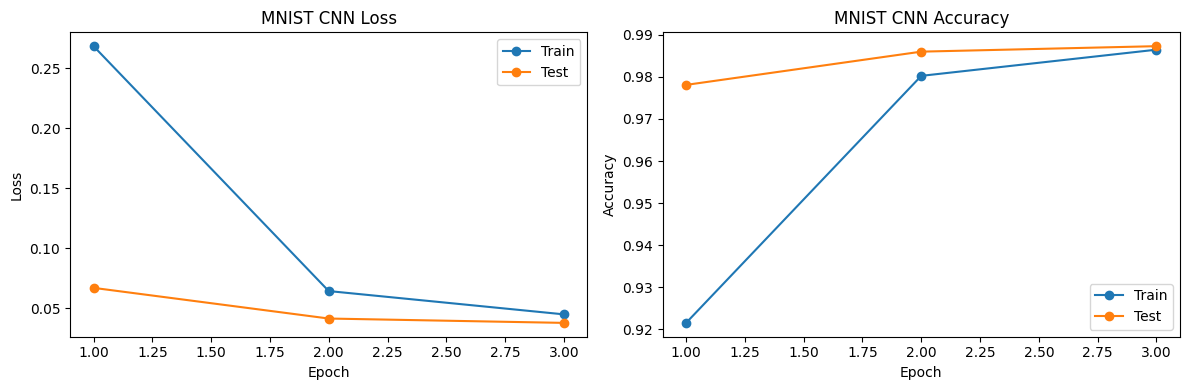

In [22]:
MNIST_EPOCHS = 3
mnist_history = fit(
    mnist_model,
    mnist_train_loader,
    mnist_test_loader,
    mnist_optimizer,
    mnist_criterion,
    device,
    epochs=MNIST_EPOCHS,
    model_name="MNIST CNN",
)
plot_history(mnist_history, title="MNIST CNN")


In [23]:
mnist_test_metrics = evaluate(
    mnist_model,
    mnist_test_loader,
    mnist_criterion,
    device,
    split_name="Test",
    model_name="MNIST CNN",
)
print(f"Final MNIST test loss: {mnist_test_metrics['loss']:.4f}")
print(f"Final MNIST test accuracy: {mnist_test_metrics['accuracy'] * 100:.2f}%")


MNIST CNN Test:   0%|          | 0/40 [00:00<?, ?it/s]

Final MNIST test loss: 0.0377
Final MNIST test accuracy: 98.73%


### Visualizing the Last-Layer Embeddings

We will collect embeddings from the hidden layer right before classification, reduce them to 2D with t-SNE, and color the points by digit class.


Embedding tensor shape: torch.Size([2500, 64])


/tmp/ipykernel_2299/2678378826.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", 10)


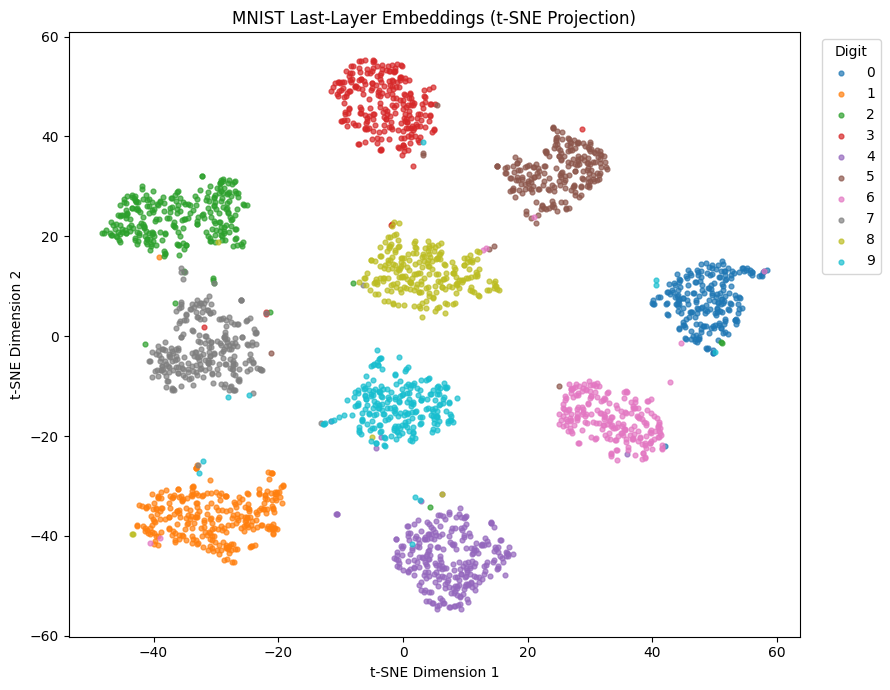

In [24]:
@torch.no_grad()
def collect_embeddings(model, loader, device, max_items=2000):
    model.eval()
    all_embeddings = []
    all_labels = []
    collected = 0

    for inputs, targets in tqdm(loader, desc="Collecting embeddings", leave=False):
        inputs = inputs.to(device)
        _, embeddings = model(inputs, return_embeddings=True)
        all_embeddings.append(embeddings.cpu())
        all_labels.append(targets.cpu())
        collected += targets.size(0)
        if collected >= max_items:
            break

    embeddings = torch.cat(all_embeddings, dim=0)[:max_items]
    labels = torch.cat(all_labels, dim=0)[:max_items]
    return embeddings, labels


mnist_embeddings, mnist_labels = collect_embeddings(mnist_model, mnist_test_loader, device, max_items=2500)
print(f"Embedding tensor shape: {mnist_embeddings.shape}")

mnist_tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=SEED,
)
mnist_embedding_2d = mnist_tsne.fit_transform(mnist_embeddings.numpy())
mnist_labels_np = mnist_labels.numpy()

plt.figure(figsize=(9, 7))
cmap = plt.cm.get_cmap("tab10", 10)
for digit in range(10):
    mask = mnist_labels_np == digit
    plt.scatter(
        mnist_embedding_2d[mask, 0],
        mnist_embedding_2d[mask, 1],
        s=12,
        alpha=0.7,
        color=cmap(digit),
        label=str(digit),
    )

plt.title("MNIST Last-Layer Embeddings (t-SNE Projection)")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(title="Digit", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Part 2: CIFAR-10 Classification

Now we will compare two approaches on CIFAR-10:

1. A **simple CNN** trained end to end.
2. A **transfer learning pipeline** where we freeze a pretrained ResNet-18, extract features, and train a small neural network on top.


In [25]:
cifar_mean = (0.4914, 0.4822, 0.4465)
cifar_std = (0.2470, 0.2435, 0.2616)

cifar_train_tfms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(cifar_mean, cifar_std),
])

cifar_test_tfms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar_mean, cifar_std),
])

cifar_train = datasets.CIFAR10(root=data_root, train=True, download=True, transform=cifar_train_tfms)
cifar_test = datasets.CIFAR10(root=data_root, train=False, download=True, transform=cifar_test_tfms)

cifar_train_loader = DataLoader(cifar_train, batch_size=128, shuffle=True, num_workers=0, pin_memory=torch.cuda.is_available())
cifar_test_loader = DataLoader(cifar_test, batch_size=256, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())

class_names = cifar_train.classes
print("CIFAR-10 classes:", class_names)
print(f"CIFAR-10 train size: {len(cifar_train)}")
print(f"CIFAR-10 test size: {len(cifar_test)}")


CIFAR-10 classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
CIFAR-10 train size: 50000
CIFAR-10 test size: 10000


In [26]:
class SimpleCIFARCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 96, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Linear(96 * 4 * 4, 160),
            nn.ReLU(),
            nn.Linear(160, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)


cifar_cnn = SimpleCIFARCNN().to(device)
cifar_criterion = nn.CrossEntropyLoss()
cifar_optimizer = torch.optim.Adam(cifar_cnn.parameters(), lr=1e-3)

total_params, trainable_params = count_parameters(cifar_cnn)
print(f"Simple CIFAR CNN total parameters: {total_params:,}")
print(f"Simple CIFAR CNN trainable parameters: {trainable_params:,}")


Simple CIFAR CNN total parameters: 322,314
Simple CIFAR CNN trainable parameters: 322,314


Simple CIFAR CNN Train 1/5:   0%|          | 0/391 [00:00<?, ?it/s]

Simple CIFAR CNN Test:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 01/5 | train loss: 1.6215 | train acc: 0.4053 | test loss: 1.3101 | test acc: 0.5308


Simple CIFAR CNN Train 2/5:   0%|          | 0/391 [00:00<?, ?it/s]

Simple CIFAR CNN Test:   0%|          | 0/40 [00:00<?, ?it/s]

...

Simple CIFAR CNN Test:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 04/5 | train loss: 0.9743 | train acc: 0.6570 | test loss: 0.8579 | test acc: 0.6971


Simple CIFAR CNN Train 5/5:   0%|          | 0/391 [00:00<?, ?it/s]

Simple CIFAR CNN Test:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 05/5 | train loss: 0.8922 | train acc: 0.6851 | test loss: 0.8497 | test acc: 0.7044


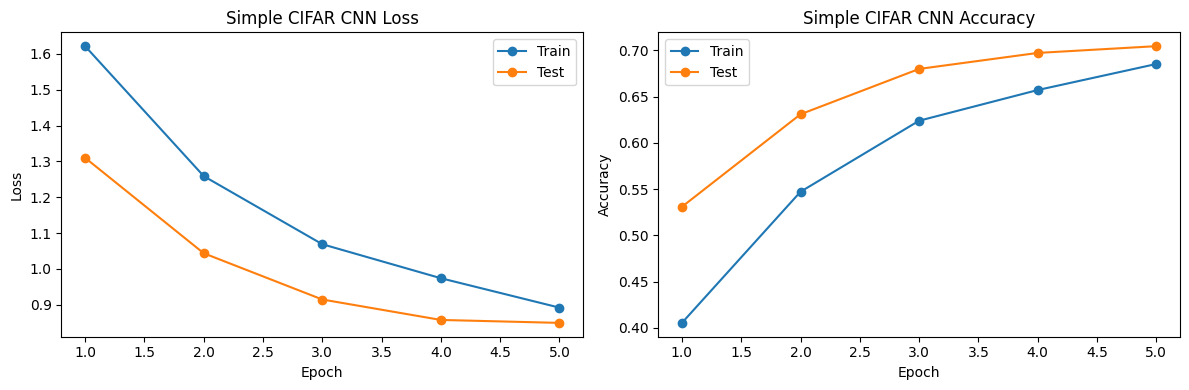

Simple CIFAR CNN Test:   0%|          | 0/40 [00:00<?, ?it/s]

Simple CNN test accuracy: 70.44%


In [27]:
CIFAR_EPOCHS = 5
cifar_history = fit(
    cifar_cnn,
    cifar_train_loader,
    cifar_test_loader,
    cifar_optimizer,
    cifar_criterion,
    device,
    epochs=CIFAR_EPOCHS,
    model_name="Simple CIFAR CNN",
)
plot_history(cifar_history, title="Simple CIFAR CNN")

cifar_test_metrics = evaluate(
    cifar_cnn,
    cifar_test_loader,
    cifar_criterion,
    device,
    split_name="Test",
    model_name="Simple CIFAR CNN",
)
print(f"Simple CNN test accuracy: {cifar_test_metrics['accuracy'] * 100:.2f}%")


### Transfer Learning with ResNet Features

For transfer learning, we will resize CIFAR-10 images to the input size expected by ResNet-18, freeze the backbone, extract features, and then train a small classifier on those features.


In [28]:
imagenet_mean = (0.485, 0.456, 0.406)
imagenet_std = (0.229, 0.224, 0.225)

resnet_train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

resnet_test_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

resnet_train_ds = datasets.CIFAR10(root=data_root, train=True, download=True, transform=resnet_train_tfms)
resnet_test_ds = datasets.CIFAR10(root=data_root, train=False, download=True, transform=resnet_test_tfms)

resnet_train_loader = DataLoader(resnet_train_ds, batch_size=64, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())
resnet_test_loader = DataLoader(resnet_test_ds, batch_size=64, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())

backbone_weights = ResNet18_Weights.DEFAULT
frozen_backbone = resnet18(weights=backbone_weights)

frozen_backbone.fc = nn.Identity()
for param in frozen_backbone.parameters():
    param.requires_grad = False
frozen_backbone = frozen_backbone.to(device)
frozen_backbone.eval()

feature_dim = 512
print("Frozen ResNet-18 feature extractor ready.")


Frozen ResNet-18 feature extractor ready.


In [29]:
@torch.no_grad()
def extract_features(backbone, loader, device):
    backbone.eval()
    feature_batches = []
    label_batches = []

    for inputs, targets in tqdm(loader, desc="Extracting ResNet features", leave=False):
        inputs = inputs.to(device)
        features = backbone(inputs)
        feature_batches.append(features.cpu())
        label_batches.append(targets)

    feature_tensor = torch.cat(feature_batches, dim=0)
    label_tensor = torch.cat(label_batches, dim=0)
    return TensorDataset(feature_tensor, label_tensor)


start = time.time()
train_feature_dataset = extract_features(frozen_backbone, resnet_train_loader, device)
test_feature_dataset = extract_features(frozen_backbone, resnet_test_loader, device)
end = time.time()

print(f"Feature extraction finished in {(end - start):.1f} seconds")
print(f"Feature tensor shape: {train_feature_dataset.tensors[0].shape}")


Extracting ResNet features:   0%|          | 0/782 [00:00<?, ?it/s]

Extracting ResNet features:   0%|          | 0/157 [00:00<?, ?it/s]

Feature extraction finished in 165.7 seconds
Feature tensor shape: torch.Size([50000, 512])


In [30]:
train_feature_loader = DataLoader(train_feature_dataset, batch_size=256, shuffle=True, num_workers=0)
test_feature_loader = DataLoader(test_feature_dataset, batch_size=256, shuffle=False, num_workers=0)


class FeatureClassifier(nn.Module):
    def __init__(self, in_features=512, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.net(x)


feature_classifier = FeatureClassifier(in_features=feature_dim, num_classes=10).to(device)
transfer_criterion = nn.CrossEntropyLoss()
transfer_optimizer = torch.optim.Adam(feature_classifier.parameters(), lr=1e-3)

total_head_params, trainable_head_params = count_parameters(feature_classifier)
backbone_total_params, backbone_trainable_params = count_parameters(frozen_backbone)

print(f"Frozen ResNet total parameters: {backbone_total_params:,}")
print(f"Frozen ResNet trainable parameters: {backbone_trainable_params:,}")
print(f"Classifier head total parameters: {total_head_params:,}")
print(f"Classifier head trainable parameters: {trainable_head_params:,}")


Frozen ResNet total parameters: 11,176,512
Frozen ResNet trainable parameters: 0
Classifier head total parameters: 133,898
Classifier head trainable parameters: 133,898


ResNet Features + NN Head Train 1/8:   0%|          | 0/196 [00:00<?, ?it/s]

ResNet Features + NN Head Test:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 01/8 | train loss: 0.5377 | train acc: 0.8249 | test loss: 0.4297 | test acc: 0.8514


ResNet Features + NN Head Train 2/8:   0%|          | 0/196 [00:00<?, ?it/s]

ResNet Features + NN Head Test:   0%|          | 0/40 [00:00<?, ?it/s]

...

ResNet Features + NN Head Test:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 07/8 | train loss: 0.2928 | train acc: 0.8967 | test loss: 0.3581 | test acc: 0.8763


ResNet Features + NN Head Train 8/8:   0%|          | 0/196 [00:00<?, ?it/s]

ResNet Features + NN Head Test:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 08/8 | train loss: 0.2827 | train acc: 0.9005 | test loss: 0.3491 | test acc: 0.8793


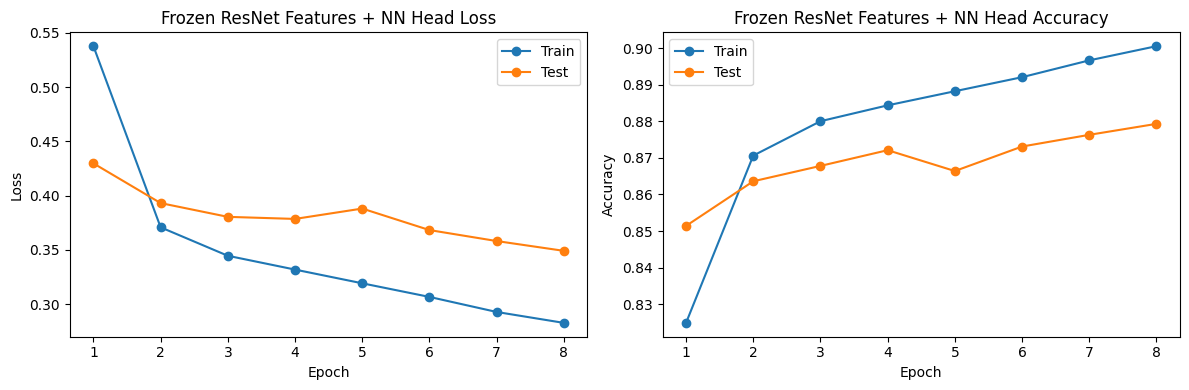

ResNet Features + NN Head Test:   0%|          | 0/40 [00:00<?, ?it/s]

Transfer learning test accuracy: 87.93%


In [31]:
TRANSFER_EPOCHS = 8
transfer_history = fit(
    feature_classifier,
    train_feature_loader,
    test_feature_loader,
    transfer_optimizer,
    transfer_criterion,
    device,
    epochs=TRANSFER_EPOCHS,
    model_name="ResNet Features + NN Head",
)
plot_history(transfer_history, title="Frozen ResNet Features + NN Head")

transfer_test_metrics = evaluate(
    feature_classifier,
    test_feature_loader,
    transfer_criterion,
    device,
    split_name="Test",
    model_name="ResNet Features + NN Head",
)
print(f"Transfer learning test accuracy: {transfer_test_metrics['accuracy'] * 100:.2f}%")


## Model Comparison

The next cell compares both CIFAR-10 approaches using parameter counts and final test accuracy.


Model                               Total Params     Trainable Params   Test Accuracy
--------------------------------------------------------------------------------------
Simple CNN                               322,314              322,314          70.44%
Frozen ResNet18 + NN Head             11,310,410              133,898          87.93%


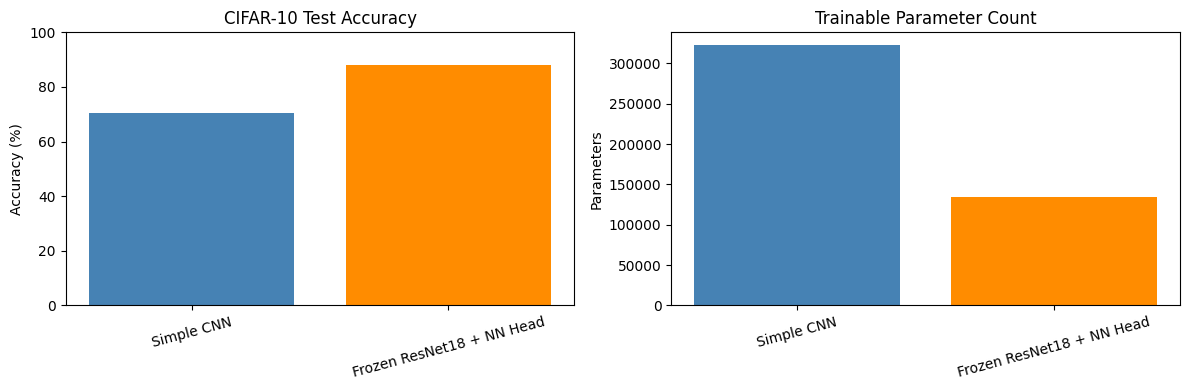

In [32]:
comparison_rows = [
    {
        "model": "Simple CNN",
        "total_params": count_parameters(cifar_cnn)[0],
        "trainable_params": count_parameters(cifar_cnn)[1],
        "test_accuracy": cifar_test_metrics["accuracy"],
    },
    {
        "model": "Frozen ResNet18 + NN Head",
        "total_params": backbone_total_params + total_head_params,
        "trainable_params": backbone_trainable_params + trainable_head_params,
        "test_accuracy": transfer_test_metrics["accuracy"],
    },
]

print(f"{'Model':32s} {'Total Params':>15s} {'Trainable Params':>20s} {'Test Accuracy':>15s}")
print("-" * 86)
for row in comparison_rows:
    print(
        f"{row['model']:32s} "
        f"{row['total_params']:15,} "
        f"{row['trainable_params']:20,} "
        f"{row['test_accuracy'] * 100:14.2f}%"
    )

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
model_names = [row["model"] for row in comparison_rows]
accuracies = [row["test_accuracy"] * 100 for row in comparison_rows]
trainable_params = [row["trainable_params"] for row in comparison_rows]

axes[0].bar(model_names, accuracies, color=["steelblue", "darkorange"])
axes[0].set_title("CIFAR-10 Test Accuracy")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(model_names, trainable_params, color=["steelblue", "darkorange"])
axes[1].set_title("Trainable Parameter Count")
axes[1].set_ylabel("Parameters")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()
